# Market Risk Analytics in Python

## Project objective

The objective of this project is to build a Python-based market risk analytics workflow for a multi-asset portfolio.

The project will measure historical risk, downside risk, diversification, stress scenario impact, and simulated future outcomes using daily market data.

This project is for educational and analytical purposes only and is not investment advice.

## Step 1: Define the portfolio

For the first version of this project, I will analyze a simplified multi-asset ETF portfolio.

The portfolio includes exposure to:

- U.S. large-cap equities
- U.S. growth equities
- U.S. small-cap equities
- Developed international equities
- Emerging-market equities
- U.S. investment-grade bonds
- Gold

The goal is not to create the perfect investment portfolio. The goal is to create a realistic portfolio that allows me to study risk, diversification, volatility, drawdowns, VaR, CVaR, stress testing, and Monte Carlo simulation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

tickers = ["SPY", "QQQ", "IWM", "EFA", "EEM", "AGG", "GLD"]

weights = np.array([0.30, 0.20, 0.10, 0.10, 0.10, 0.15, 0.05])

portfolio = pd.DataFrame({
    "Ticker": tickers,
    "Weight": weights,
    "Weight (%)": weights * 100,
    "Role": [
        "U.S. large-cap equity exposure",
        "U.S. growth and technology exposure",
        "U.S. small-cap equity exposure",
        "Developed international equity exposure",
        "Emerging-market equity exposure",
        "U.S. investment-grade bond exposure",
        "Gold / alternative defensive exposure"
    ]
})

portfolio

,Ticker,Weight,Weight (%),Role
0,SPY,0.30,30.0,U.S. large-cap equity exposure
1,QQQ,0.20,20.0,U.S. growth and technology exposure
2,IWM,0.10,10.0,U.S. small-cap equity exposure
3,EFA,0.10,10.0,Developed international equity exposure
4,EEM,0.10,10.0,Emerging-market equity exposure
5,AGG,0.15,15.0,U.S. investment-grade bond exposure
6,GLD,0.05,5.0,Gold / alternative defensive exposure


In [2]:
if not np.isclose(weights.sum(), 1.0):
    raise ValueError("Portfolio weights must sum to 1.")

print(f"Total portfolio weight: {weights.sum():.2%}")

Total portfolio weight: 100.00%


## Step 2: Choose the analysis period

For this project, I will use daily historical data from 2019-01-01 to the latest available market data at the time the notebook is run.

This period was selected because it includes multiple market environments, including the COVID-19 crash, the post-COVID recovery, the 2022 inflation and interest-rate shock, the 2023–2024 recovery period, and the most recent market conditions.

Because the end date updates when the notebook is rerun, the results may change over time. This makes the project more realistic as a living market risk analytics workflow.

In [3]:
start_date = "2019-01-01"
end_date = None  # Use latest available market data

print(f"Analysis period starts on: {start_date}")
print("Analysis period ends at the latest available market data.")

Analysis period starts on: 2019-01-01
Analysis period ends at the latest available market data.


## Step 3: Download historical price data

In this step, I download daily historical adjusted closing prices for all selected ETFs.

Adjusted prices are used because they account for corporate actions such as dividends and splits, making them more appropriate for return and risk calculations.

In [4]:
import yfinance as yf

price_data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False
)

prices = price_data["Close"]

prices.head()

/Users/jimenachinchilla/market-risk-analytics-python/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Ticker,AGG,EEM,EFA,GLD,IWM,QQQ,SPY
Date,,,,,,,
2019-01-02,86.043808,33.319099,47.469456,121.330002,122.977829,148.040878,224.382523
2019-01-03,86.399025,32.714989,47.040565,122.430000,120.776901,143.204300,219.028152
2019-01-04,86.140656,33.770039,48.480995,121.440002,125.288330,149.331223,226.364624
2019-01-07,85.995308,33.846619,48.667114,121.860001,127.480156,151.109070,228.149445
2019-01-08,85.930740,33.974243,48.982708,121.529999,129.434464,152.475983,230.293015


In [5]:
print("Price data shape:", prices.shape)
print("Start date:", prices.index.min())
print("End date:", prices.index.max())

prices.tail()

Price data shape: (1873, 7)
Start date: 2019-01-02 00:00:00
End date: 2026-06-15 00:00:00


Ticker,AGG,EEM,EFA,GLD,IWM,QQQ,SPY
Date,,,,,,,
2026-06-09,98.370003,65.820000,102.900002,390.779999,285.019989,707.830017,737.049988
2026-06-10,98.309998,64.660004,101.570000,374.579987,282.049988,693.690002,725.429993
2026-06-11,98.879997,67.500000,104.730003,386.320007,290.410004,717.119995,737.760010
2026-06-12,98.760002,67.879997,105.019997,386.540009,292.950012,721.340027,741.750000
2026-06-15,98.849998,69.750000,104.080002,396.549988,294.640015,744.000000,754.830017


In [6]:
missing_values = pd.DataFrame({
    "Missing Values": prices.isna().sum(),
    "Missing (%)": prices.isna().mean() * 100
})

missing_values

,Missing Values,Missing (%)
Ticker,,
AGG,0,0.0
EEM,0,0.0
EFA,0,0.0
GLD,0,0.0
IWM,0,0.0
QQQ,0,0.0
SPY,0,0.0


In [7]:
prices = prices.dropna()

print("Cleaned price data shape:", prices.shape)
print("Cleaned start date:", prices.index.min())
print("Cleaned end date:", prices.index.max())

Cleaned price data shape: (1873, 7)
Cleaned start date: 2019-01-02 00:00:00
Cleaned end date: 2026-06-15 00:00:00


## Step 4: Calculate daily returns

In this step, I convert adjusted closing prices into daily percentage returns.

Risk modeling is based on returns rather than raw prices because returns measure the relative change in value over time.

For the first version of this project, I will use simple daily returns instead of log returns because they are easier to interpret and communicate.

In [8]:
returns = prices.pct_change().dropna()

returns.head()

Ticker,AGG,EEM,EFA,GLD,IWM,QQQ,SPY
Date,,,,,,,
2019-01-03,0.004128,-0.018131,-0.009035,0.009066,-0.017897,-0.032671,-0.023863
2019-01-04,-0.002990,0.032250,0.030621,-0.008086,0.037353,0.042784,0.033496
2019-01-07,-0.001687,0.002268,0.003839,0.003458,0.017494,0.011905,0.007885
2019-01-08,-0.000751,0.003771,0.006485,-0.002708,0.015330,0.009046,0.009395
2019-01-09,0.000845,0.017781,0.011234,0.006418,0.008255,0.008149,0.004673


In [9]:
print("Returns data shape:", returns.shape)
print("Start date:", returns.index.min())
print("End date:", returns.index.max())

returns.describe()

Returns data shape: (1872, 7)
Start date: 2019-01-03 00:00:00
End date: 2026-06-15 00:00:00


Ticker,AGG,EEM,EFA,GLD,IWM,QQQ,SPY
count,1872.000000,1872.000000,1872.000000,1872.000000,1872.000000,1872.000000,1872.000000
mean,0.000081,0.000487,0.000488,0.000694,0.000593,0.000977,0.000724
std,0.003808,0.013516,0.011662,0.011021,0.015846,0.015121,0.012273
min,-0.040011,-0.124793,-0.109902,-0.102742,-0.132669,-0.119788,-0.109424
25%,-0.001743,-0.006098,-0.005132,-0.004760,-0.007936,-0.005942,-0.004241
50%,0.000180,0.000900,0.000768,0.000850,0.001008,0.001445,0.001005
75%,0.001938,0.007447,0.006490,0.006262,0.009570,0.008827,0.006644
max,0.023721,0.080529,0.084731,0.063587,0.091492,0.120031,0.105019


In [10]:
portfolio_returns = returns @ weights

portfolio_returns.head()

Date
2019-01-03   -0.010268
2019-01-04    0.019634
2019-01-07    0.004607
2019-01-08    0.004266
2019-01-09    0.007857
dtype: float64

In [11]:
portfolio_returns_summary = pd.DataFrame({
    "Metric": [
        "Mean Daily Return",
        "Daily Volatility",
        "Minimum Daily Return",
        "Maximum Daily Return"
    ],
    "Value": [
        portfolio_returns.mean(),
        portfolio_returns.std(),
        portfolio_returns.min(),
        portfolio_returns.max()
    ]
})

portfolio_returns_summary

,Metric,Value
0,Mean Daily Return,0.000482
1,Daily Volatility,0.008232
2,Minimum Daily Return,-0.076592
3,Maximum Daily Return,0.057710


In [12]:
cumulative_returns = (1 + portfolio_returns).cumprod()

cumulative_returns.head()

Date
2019-01-03    0.989732
2019-01-04    1.009164
2019-01-07    1.013813
2019-01-08    1.018138
2019-01-09    1.026138
dtype: float64

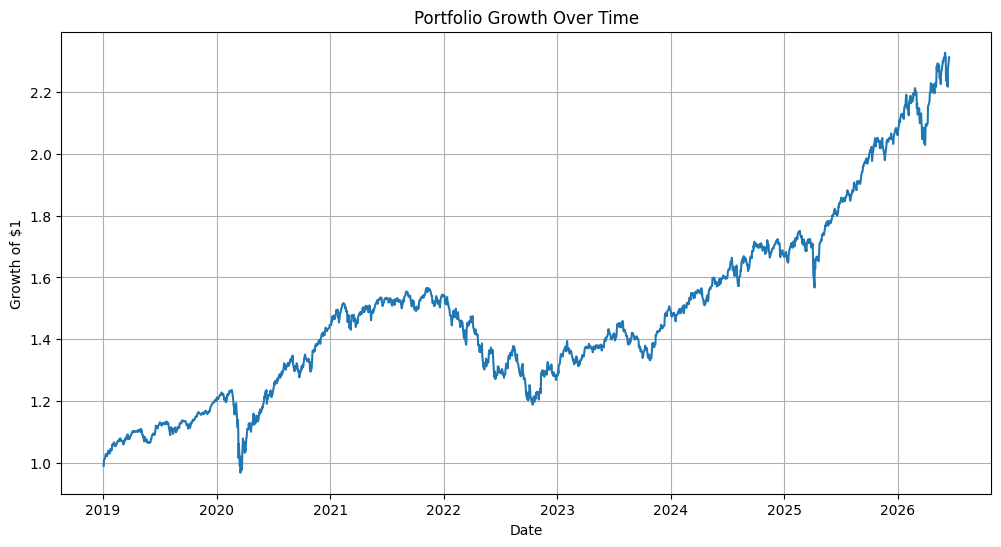

In [13]:
plt.figure(figsize=(12, 6))
plt.plot(cumulative_returns)
plt.title("Portfolio Growth Over Time")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.show()

## Step 5: Measure historical portfolio risk

In this step, I calculate the main historical risk metrics for the portfolio:

- Annualized return
- Annualized volatility
- Sharpe ratio
- Maximum drawdown
- Historical Value at Risk (VaR)
- Historical Conditional Value at Risk (CVaR)

These metrics help quantify return, risk, downside losses, and extreme loss behavior.

In [14]:
trading_days = 252
annual_risk_free_rate = 0.00  # Baseline assumption for first version

annualized_return = (1 + portfolio_returns.mean()) ** trading_days - 1
annualized_volatility = portfolio_returns.std() * np.sqrt(trading_days)

sharpe_ratio = (annualized_return - annual_risk_free_rate) / annualized_volatility

annualized_return, annualized_volatility, sharpe_ratio

(np.float64(0.12911114529498757),
 np.float64(0.13067998089087887),
 np.float64(0.98799482839532))

In [15]:
running_max = cumulative_returns.cummax()
drawdown = cumulative_returns / running_max - 1

max_drawdown = drawdown.min()

max_drawdown

np.float64(-0.2413691737745175)

In [16]:
confidence_level = 0.95

var_95 = portfolio_returns.quantile(1 - confidence_level)
cvar_95 = portfolio_returns[portfolio_returns <= var_95].mean()

var_95, cvar_95

(np.float64(-0.012094687976105299), np.float64(-0.01915258627428513))

In [ ]:
risk_summary = pd.DataFrame({
    "Metric": [
        "Annualized Return",
        "Annualized Volatility",
        "Sharpe Ratio",
        "Maximum Drawdown",
        "Historical VaR 95%",
        "Historical CVaR 95%"
    ],
    "Value": [
        annualized_return,
        annualized_volatility,
        sharpe_ratio,
        max_drawdown,
        var_95,
        cvar_95
    ]
})

risk_summary

In [ ]:
risk_summary_display = risk_summary.copy()

risk_summary_display["Value"] = risk_summary_display.apply(
    lambda row: f"{row['Value']:.2f}" if row["Metric"] == "Sharpe Ratio" else f"{row['Value']:.2%}",
    axis=1
)

risk_summary_display

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(drawdown)
plt.title("Portfolio Drawdown Over Time")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(True)
plt.show()

### Initial interpretation

The annualized return shows the average yearly growth rate of the portfolio over the selected historical period.

The annualized volatility measures how much the portfolio returns fluctuate over time.

The Sharpe ratio compares return to risk. In this first version, I assume a 0% risk-free rate as a baseline assumption.

Maximum drawdown shows the worst peak-to-trough decline experienced by the portfolio.

Historical VaR at 95% estimates the daily loss threshold that was only exceeded in the worst 5% of historical days.

Historical CVaR at 95% estimates the average loss on days when losses were worse than the VaR threshold.

## Step 6: Correlation and diversification analysis

In this step, I analyze how the assets move relative to each other.

Correlation is important in risk modeling because a portfolio may appear diversified by holding many assets, but if those assets move together during market stress, the actual diversification benefit may be limited.

I also calculate each asset's contribution to total portfolio risk.

In [ ]:
correlation_matrix = returns.corr()

correlation_matrix

In [ ]:
plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45)
plt.yticks(range(len(correlation_matrix.index)), correlation_matrix.index)

plt.title("Asset Return Correlation Matrix")
plt.show()

In [ ]:
# Calculate each asset's average correlation with the rest of the portfolio

correlation_without_self = correlation_matrix.copy()

np.fill_diagonal(correlation_without_self.values, np.nan)

average_correlation = correlation_without_self.mean().sort_values(ascending=False)

average_correlation

In [ ]:
# Annualized covariance matrix
cov_matrix = returns.cov() * trading_days

# Convert weights into a pandas Series so labels stay aligned
weights_series = pd.Series(weights, index=tickers)

# Portfolio volatility using covariance matrix
portfolio_variance = weights_series.T @ cov_matrix @ weights_series
portfolio_volatility_from_cov = np.sqrt(portfolio_variance)

portfolio_volatility_from_cov

In [ ]:
# Marginal contribution to risk
marginal_risk_contribution = cov_matrix @ weights_series / portfolio_volatility_from_cov

# Total contribution to portfolio volatility
risk_contribution = weights_series * marginal_risk_contribution

# Percentage contribution to portfolio volatility
risk_contribution_percent = risk_contribution / portfolio_volatility_from_cov

risk_contribution_table = pd.DataFrame({
    "Weight": weights_series,
    "Marginal Risk Contribution": marginal_risk_contribution,
    "Risk Contribution": risk_contribution,
    "Risk Contribution (%)": risk_contribution_percent
}).sort_values("Risk Contribution (%)", ascending=False)

risk_contribution_table

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(risk_contribution_table.index, risk_contribution_table["Risk Contribution (%)"])
plt.title("Risk Contribution by Asset")
plt.xlabel("Asset")
plt.ylabel("Contribution to Portfolio Risk")
plt.grid(True)
plt.show()

### Correlation and diversification interpretation

The correlation matrix shows how closely the assets move together.

Assets with high positive correlations may provide less diversification benefit because they tend to rise and fall together.

Assets with lower or negative correlations may provide more diversification benefit because they behave differently from the rest of the portfolio.

The risk contribution analysis shows which assets contribute the most to total portfolio volatility. An asset can have a smaller portfolio weight but still contribute meaningfully to risk if it has high volatility or high correlation with other assets.

## Step 7: Stress testing

In this step, I apply hypothetical market shock scenarios to estimate how the portfolio could behave under stressed conditions.

Stress testing is useful because historical averages may hide large downside risks. Instead of only asking “what happened on average?”, stress testing asks “what could happen if a bad market scenario occurs?”

Each scenario applies assumed percentage shocks to the assets in the portfolio. The total portfolio impact is calculated by multiplying each asset shock by its portfolio weight.

In [ ]:
# Make sure weights are aligned with tickers
weights_series = pd.Series(weights, index=tickers)

stress_scenarios = pd.DataFrame({
    "Equity Market Crash": {
        "SPY": -0.20,
        "QQQ": -0.25,
        "IWM": -0.25,
        "EFA": -0.18,
        "EEM": -0.22,
        "AGG": 0.02,
        "GLD": 0.05
    },
    "Technology Selloff": {
        "SPY": -0.10,
        "QQQ": -0.30,
        "IWM": -0.12,
        "EFA": -0.08,
        "EEM": -0.10,
        "AGG": 0.01,
        "GLD": 0.02
    },
    "Interest Rate Shock": {
        "SPY": -0.08,
        "QQQ": -0.12,
        "IWM": -0.10,
        "EFA": -0.06,
        "EEM": -0.08,
        "AGG": -0.07,
        "GLD": -0.03
    },
    "Emerging Market Crisis": {
        "SPY": -0.05,
        "QQQ": -0.06,
        "IWM": -0.07,
        "EFA": -0.10,
        "EEM": -0.30,
        "AGG": 0.01,
        "GLD": 0.03
    },
    "Broad Risk-Off Event": {
        "SPY": -0.15,
        "QQQ": -0.18,
        "IWM": -0.20,
        "EFA": -0.15,
        "EEM": -0.20,
        "AGG": -0.03,
        "GLD": 0.04
    }
}).T

stress_scenarios

In [ ]:
stress_results = stress_scenarios.copy()

stress_results["Portfolio Impact"] = stress_scenarios @ weights_series

stress_results

In [ ]:
stress_results_display = stress_results.copy()

for column in stress_results_display.columns:
    stress_results_display[column] = stress_results_display[column].map(lambda x: f"{x:.2%}")

stress_results_display

In [ ]:
initial_portfolio_value = 10_000

stress_loss_table = pd.DataFrame({
    "Scenario": stress_results.index,
    "Portfolio Impact": stress_results["Portfolio Impact"],
    "Estimated Portfolio Value": initial_portfolio_value * (1 + stress_results["Portfolio Impact"]),
    "Estimated Dollar Gain/Loss": initial_portfolio_value * stress_results["Portfolio Impact"]
})

stress_loss_table

In [ ]:
stress_loss_table_display = stress_loss_table.copy()

stress_loss_table_display["Portfolio Impact"] = stress_loss_table_display["Portfolio Impact"].map(lambda x: f"{x:.2%}")
stress_loss_table_display["Estimated Portfolio Value"] = stress_loss_table_display["Estimated Portfolio Value"].map(lambda x: f"${x:,.2f}")
stress_loss_table_display["Estimated Dollar Gain/Loss"] = stress_loss_table_display["Estimated Dollar Gain/Loss"].map(lambda x: f"${x:,.2f}")

stress_loss_table_display

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(stress_results.index, stress_results["Portfolio Impact"])
plt.title("Portfolio Impact Under Stress Scenarios")
plt.xlabel("Stress Scenario")
plt.ylabel("Estimated Portfolio Impact")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### Stress testing interpretation

The stress test estimates how the portfolio could respond to different hypothetical market shocks.

The portfolio impact depends on both the size of the shock applied to each asset and the weight of each asset in the portfolio.

Equity-heavy scenarios are expected to hurt the portfolio because most of the portfolio is allocated to equity ETFs.

Bonds and gold may reduce losses in some scenarios, but they may not fully protect the portfolio if the shock affects multiple asset classes at the same time.

The stress test is not a prediction. It is a scenario-based risk tool used to understand possible downside exposure under specific assumptions.